---
title: earthkit-meteo: extreme
short_title: Extreme
---

## Earthkit-meteo: extreme indices

In this notebook you will see how to:

- compute the Extreme Forecast Index (EFI) from GRIB/Xarray data
- plot the resulting EFI field
- compute the Shift of Tails (SOT) as a complement to EFI

### Getting the data

The sample forecast contains ensemble 2 m temperature data and the second sample contains the corresponding model-climate information. EFI and SOT compare the forecast distribution against that model climate for the same parameter, lead time and time of year.

In [1]:
import earthkit.data as ekd
from earthkit.meteo import extreme
import earthkit.plots as ekp

ds_fc = ekd.from_source("sample", "extreme_2t_fc.grib").to_xarray()
ds_fc

<xarray.Dataset> Size: 347MB
Dimensions:    (member: 101, values: 421120)
Coordinates:
  * member     (member) <U3 1kB '0' '1' '10' '100' '11' ... '96' '97' '98' '99'
    latitude   (values) float64 3MB ...
    longitude  (values) float64 3MB ...
Dimensions without coordinates: values
Data variables:
    2t         (member, values) float64 340MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Next, we load the model-climate data used as the reference distribution.

In [2]:
ds_clim = ekd.from_source("sample", "extreme_2t_clim.grib").to_xarray()
ds_clim

<xarray.Dataset> Size: 347MB
Dimensions:    (member: 101, values: 421120)
Coordinates:
  * member     (member) <U3 1kB '0' '1' '10' '100' '11' ... '96' '97' '98' '99'
    latitude   (values) float64 3MB ...
    longitude  (values) float64 3MB ...
Dimensions without coordinates: values
Data variables:
    avg_2t     (member, values) float64 340MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

### Extreme Forecast Index

EFI measures how unusual the ensemble forecast distribution is relative to model climate. ECMWF defines it from the difference between the forecast and model-climate cumulative distribution functions, with extra weight given to the tails of the distribution. EFI values lie between -1 and 1. In practice, EFI values around 0.5 to 0.8 often indicate unusual conditions, while values above about 0.8 suggest very unusual or extreme conditions. For 2 m temperature, positive EFI highlights unusually warm conditions and negative EFI highlights unusually cold conditions.

References: [ECMWF Forecast User Guide: EFI and SOT overview](https://confluence.ecmwf.int/display/FUG/Section%2B8.1.9%2BExtreme%2BForecast%2BIndex%2B-%2BEFI%2C%2Band%2BShift%2Bof%2BTails%2B-%2BSOT), [ECMWF Forecast User Guide: calculating EFI](https://confluence.ecmwf.int/display/FUG/Section%2B8.1.9.2%2BExtreme%2BForecast%2BIndex%2B-%2BEFI), [Introducing earthkit](https://www.ecmwf.int/en/newsletter/179/computing/introducing-earthkit).

We compute EFI with `earthkit.meteo.extreme.efi()` using the forecast temperature field and the average 2 m temperature model-climate field.

In [ ]:
efi = extreme.efi(ds_fc["2t"], ds_clim["avg_2t"])


<xarray.DataArray '2t' (values: 421120)> Size: 3MB
array([-0.63844876, -0.63113266, -0.6209948 , ...,  0.23228553,
        0.25972762,  0.27982915], shape=(421120,))
Coordinates:
    latitude   (values) float64 3MB 89.78 89.78 89.78 ... -89.78 -89.78 -89.78
    longitude  (values) float64 3MB 0.0 18.0 36.0 54.0 ... 306.0 324.0 342.0
Dimensions without coordinates: values
Attributes:
    standard_name:  unknown
    long_name:      2 metre temperature
    units:          kelvin
    level_type:     surface
    _earthkit:      {'message': b'GRIB\x00\x05\xa2\x01\x00\x00j\x80b\x9e\xff\...
    ek_grid_spec:   {"grid": "O320"}

Finally, we plot the EFI field to identify the regions where the forecast departs most strongly from model climate. This version keeps the custom map styling added in the concurrent changes.

CACHE-MANAGER mir/weights, /tmp/cache does not exist
CACHE-MANAGER mir/weights, /tmp/cache created
Cache file /tmp/cache/mir/weights/18/linear/R320-440b952c43f5fbe93a3d5b38b159f738-89.7849:0:-89.7849:359.722/LL-0.2x0.2-90:0:-90:359.8-97e55a2ad36fcc75e48942e5dc482a65.mat does not exist
Creating cache file /tmp/cache/mir/weights/18/linear/R320-440b952c43f5fbe93a3d5b38b159f738-89.7849:0:-89.7849:359.722/LL-0.2x0.2-90:0:-90:359.8-97e55a2ad36fcc75e48942e5dc482a65.mat
CacheManager creating file /tmp/cache/mir/weights/18/linear/R320-440b952c43f5fbe93a3d5b38b159f738-89.7849:0:-89.7849:359.722/LL-0.2x0.2-90:0:-90:359.8-97e55a2ad36fcc75e48942e5dc482a65.mat


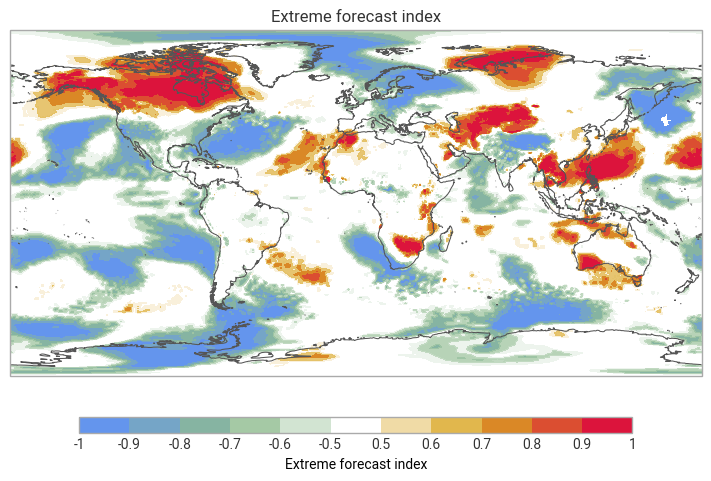

In [4]:
from earthkit.plots.resample import Regrid

style = ekp.styles.Style(
    levels=[-1, -0.9, -0.8, -0.7, -0.6, -0.5, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    colors=["cornflowerblue", "darkseagreen", (1, 1, 1, 0), "goldenrod", "crimson"],
)

chart = ekp.Map()

chart.contourf(
    efi,
    resample=Regrid(in_grid={"grid": "O320"}),
    style=style,
)

chart.coastlines()
chart.title("Extreme forecast index")
chart.legend(label="Extreme forecast index")

chart.show()

### Shift of Tails

SOT complements EFI. ECMWF notes that EFI alone does not distinguish between ensemble members that merely reach the model-climate extreme and members that go well beyond it. SOT was introduced to describe how far the forecast tail extends relative to model climate. In the upper tail, ECMWF defines SOT from the 90th and 99th percentiles of the ensemble and model-climate distributions. Positive SOT indicates that at least 10% of the ensemble is forecasting an extreme event.

Reference: [ECMWF Forecast User Guide: calculating SOT](https://confluence.ecmwf.int/display/FUG/Section%2B8.1.9.3%2BCalculating%2Bthe%2BShift%2Bof%2BTails%2B-%2BSOT).

The example below uses the same forecast and climate inputs. The exact availability of `extreme.sot()` depends on the installed `earthkit-meteo` version, so the cell checks for it explicitly.

In [6]:
sot = extreme.sot(ds_fc["2t"], ds_clim["avg_2t"], 90)
sot

<xarray.DataArray '2t' (values: 421120)> Size: 3MB
array([-1.06094099, -1.58976283, -1.9806669 , ...,  5.82532767,
        6.50099305,  7.20328126], shape=(421120,))
Coordinates:
    latitude   (values) float64 3MB 89.78 89.78 89.78 ... -89.78 -89.78 -89.78
    longitude  (values) float64 3MB 0.0 18.0 36.0 54.0 ... 306.0 324.0 342.0
Dimensions without coordinates: values
Attributes:
    standard_name:  unknown
    long_name:      2 metre temperature
    units:          kelvin
    level_type:     surface
    _earthkit:      {'message': b'GRIB\x00\x05\xa2\x01\x00\x00j\x80b\x9e\xff\...
    ek_grid_spec:   {"grid": "O320"}

As with EFI, a quick plot is useful for checking where the most pronounced tail shifts are located.

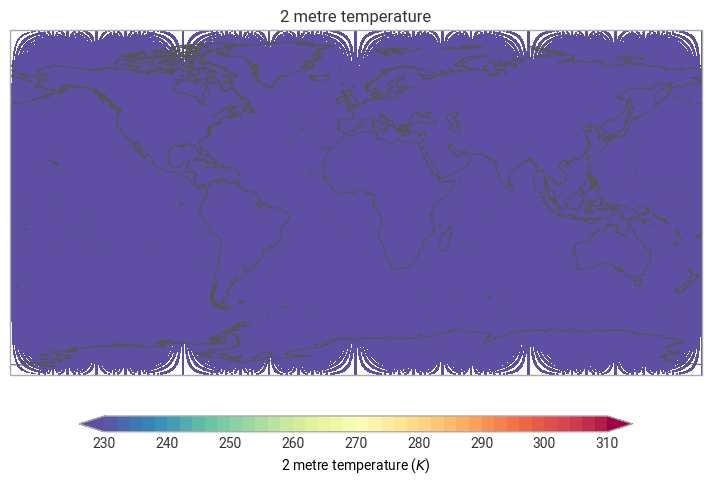

In [7]:
ekp.quickplot(sot).show()